<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment_10:Customer Review Sentiment Analysis

**Problem statement:**

Restaurants receive many customer reviews every day, making it difficult to manually determine whether feedback is positive or negative. the goal of this assignment is to build a sentiment analysis model that uses the review text to predict whether a customer liked the restaurant (positive sentiment) or did not like it negative(sentiment)

**The dataset**

dataset consists of authentic restaurant reviews, providing valuable insights into customer sentiments
The dataset consists of 1000 rows and 2 columns. Review Column consist of customer reviews and like column consist of 0 and 1. If the review is positive, 1 and if negative, 0.


data source from kaggle (Data files © Original Authors)

Import all the necessary libraries for data handling, visualization, and model building

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
import string
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import tkinter as tk
from tkinter import ttk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Loading the data set

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data_set/Restaurant_Reviews.tsv", sep='\t')
df.head(2)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0


Checking the missing values.

In [ ]:
df.isnull().sum()

,0
Review,0
Liked,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


the data has no missing values and type of data is consistency it align with the columns.

Preprocessing:

Since the dataset is small, I used stop word
removal for text cleaning instead of connecting to the OpenAI API.


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))
negations = {'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't",
                    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't",
                    'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
                    'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't",
                    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}

stop_words = stop_words - negations

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
ps = PorterStemmer()
def clean_text(text):
    review = re.sub(r'[^a-zA-Z]', ' ', text)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if word not in stop_words]
    review = " ".join(review)
    return review


In [ ]:
df["clean_review"] = df["Review"].apply(clean_text)


In [ ]:
print("\nSample before/after cleaning:")
print(df[["Review", "clean_review"]].head(3).to_string(index=False))



Sample before/after cleaning:
                                   Review           clean_review
                 Wow... Loved this place.         wow love place
                       Crust is not good.         crust not good
Not tasty and the texture was just nasty. not tasti textur nasti


In [ ]:
words = df["clean_review"].tolist()
print("\nCleaned Reviews:")
print(words[:5])


Cleaned Reviews:
['wow love place', 'crust not good', 'not tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price']


Frequent words that are in liked

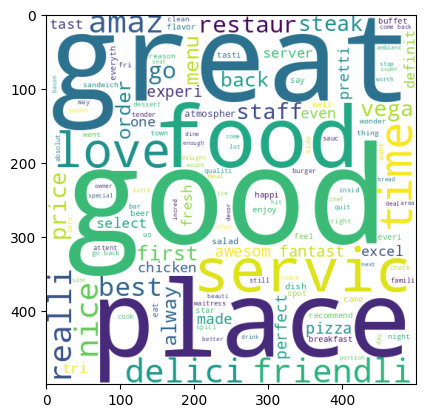

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=8,background_color="white")
pos = wc.generate(df[df['Liked']==1]['clean_review'].str.cat(sep=" "))
plt.imshow(pos)

Frequent words in negative commonets

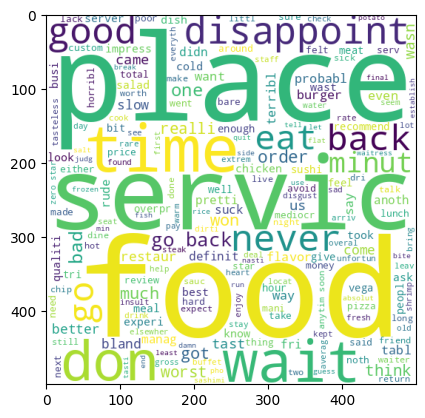

In [ ]:
wc = WordCloud(width=500,height=500,min_font_size=8,background_color="white")
pos = wc.generate(df[df['Liked']==0]['clean_review'].str.cat(sep=" "))
plt.imshow(pos)

Categorical / scaling notes:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(words).toarray()
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

predicted column assigned as y

In [ ]:
y = df['Liked']

Splitting the data set

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.20,random_state=42)

logistic regression

since the out put is binary i choose logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr =LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.795

RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf =RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.795

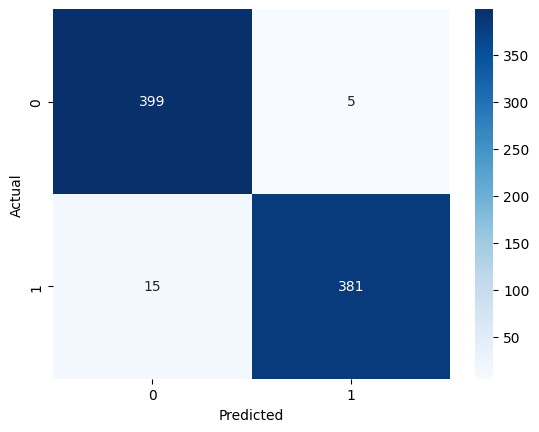

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       404
           1       0.99      0.96      0.97       396

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.97       800
weighted avg       0.98      0.97      0.97       800



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

y_pred = lr.predict(X_train)

cm = confusion_matrix(y_train, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(y_train, y_pred))

**In conclusion**

The model performs very well in predicting positive comments. It achieved 99% precision and 96% recall for the positive class, meaning most comments predicted as positive are correct, although a small number of positive comments were missed.
and over all the model performed very well, achieving an overall accuracy of 97%. It classified both positive and negative comments with high precision and recall, making it a reliable model for sentiment analysis. Although a few comments were misclassified, the overall performance indicates that the model is accurate and well-balanced.
